In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print(tf.__version__)
print(os.getcwd())

2.21.0
C:\Users\shind\PycharmProjects\WelcomeScreen


In [4]:
import zipfile, os

zip_path = r"C:\Users\shind\Downloads\dogs vs  cat  dataset.zip"
extract_to = r"C:\Users\shind\Downloads\dogcat_data"

with zipfile.ZipFile(zip_path) as z:
    z.extractall(extract_to)

print(os.listdir(extract_to))

['catsvsdogs', 'test', 'train']


In [5]:
import os
base = r"C:\Users\shind\Downloads\dogcat_data"

for name in ["train", "test", "catsvsdogs"]:
    p = os.path.join(base, name)
    items = os.listdir(p)
    print(name, "->", len(items), "items:", items[:6])

train -> 3 items: ['cats', 'dogs', 'others']
test -> 3 items: ['cats', 'dogs', 'others']
catsvsdogs -> 2 items: ['test', 'train']


In [6]:
TRAIN_DIR = r"C:\Users\shind\Downloads\dogcat_data\train"
TEST_DIR = r"C:\Users\shind\Downloads\dogcat_data\test"

print(os.listdir(TRAIN_DIR))
print(len(os.listdir(os.path.join(TRAIN_DIR, "cats"))), "cat images")
print(len(os.listdir(os.path.join(TRAIN_DIR, "dogs"))), "dog images")

['cats', 'dogs', 'others']
10000 cat images
10000 dog images


In [7]:
IMG_SIZE = (128, 128)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
print(class_names)   # ['cats', 'dogs']

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 23501 files belonging to 3 classes.
Using 18801 files for training.
Found 23501 files belonging to 3 classes.
Using 4700 files for validation.
Found 6299 files belonging to 3 classes.
['cats', 'dogs', 'others']


In [8]:
print('model' in globals())


False


In [9]:
model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Rescaling(1.0 / 255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
 history = model.fit(train_ds, validation_data=val_ds, epochs=2)

Epoch 1/2


C:\Users\shind\PycharmProjects\WelcomeScreen\.venv312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


588/588 ━━━━━━━━━━━━━━━━━━━━ 169s 248ms/step - accuracy: 0.4572 - loss: -361158112.0000 - val_accuracy: 0.4438 - val_loss: -2463456256.0000
Epoch 2/2
588/588 ━━━━━━━━━━━━━━━━━━━━ 140s 214ms/step - accuracy: 0.4580 - loss: -33082310656.0000 - val_accuracy: 0.4445 - val_loss: -105891880960.0000


In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

197/197 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.4305 - loss: -159442305024.0000
Test accuracy: 0.431


In [12]:
base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base.trainable = False   # keep the pretrained features frozen

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)   # MobileNetV2 expects -1 to 1
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

tl_model = tf.keras.Model(inputs, outputs)
tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss="binary_crossentropy", metrics=["accuracy"])

In [13]:
history = tl_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 140s 213ms/step - accuracy: 0.7536 - loss: -6.0143 - val_accuracy: 0.7445 - val_loss: -13.4616
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 131s 206ms/step - accuracy: 0.7558 - loss: -18.6470 - val_accuracy: 0.7391 - val_loss: -27.2275
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 133s 210ms/step - accuracy: 0.7540 - loss: -31.1518 - val_accuracy: 0.7372 - val_loss: -40.9089
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 121s 191ms/step - accuracy: 0.7552 - loss: -43.7320 - val_accuracy: 0.7432 - val_loss: -54.5775
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 122s 192ms/step - accuracy: 0.7563 - loss: -56.2851 - val_accuracy: 0.7366 - val_loss: -68.2697


In [14]:
test_loss, test_acc = tl_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

197/197 ━━━━━━━━━━━━━━━━━━━━ 30s 152ms/step - accuracy: 0.6979 - loss: -90.1955
Test accuracy: 0.698


In [15]:
tl_model.save("cat_dog_mobilenet.keras")

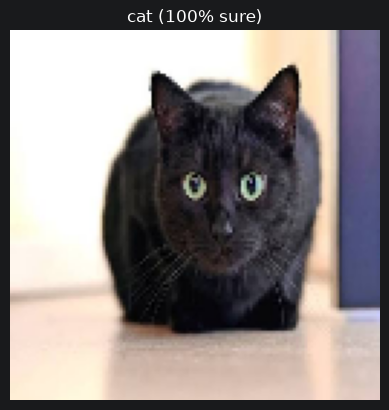

In [16]:
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

def predict_image(path):
    img = load_img(path, target_size=IMG_SIZE)
    arr = np.expand_dims(img_to_array(img), axis=0)
    p = float(tl_model.predict(arr, verbose=0)[0][0])
    label = "dog" if p > 0.5 else "cat"
    conf = p if p > 0.5 else 1 - p

    plt.imshow(img)
    plt.title(f"{label} ({conf:.0%} sure)")
    plt.axis("off")
    plt.show()

predict_image(r"C:\Users\shind\Downloads\images.jpg")

In [17]:
tl_model = tf.keras.models.load_model("cat_dog_mobilenet.keras")
IMG_SIZE = (128, 128)

In [18]:
def predict_image(path, threshold=0.85):
    img = load_img(path, target_size=IMG_SIZE)
    arr = np.expand_dims(img_to_array(img), axis=0)
    p = float(tl_model.predict(arr, verbose=0)[0][0])
    conf = p if p > 0.5 else 1 - p

    if conf < threshold:
        label = "not sure / maybe not a cat or dog"
    else:
        label = "dog" if p > 0.5 else "cat"

    plt.imshow(img)
    plt.title(f"{label} ({conf:.0%})")
    plt.axis("off")
    plt.show()

In [19]:
layers.Dense(3, activation="softmax")

<Dense name=dense_3, built=False>

In [20]:
import pathlib, shutil, os

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file("flower_photos", origin=url, untar=True)
flowers = pathlib.Path(archive)

others_train = os.path.join(TRAIN_DIR, "others")
others_test = os.path.join(TEST_DIR, "others")
os.makedirs(others_train, exist_ok=True)
os.makedirs(others_test, exist_ok=True)

files = [f for f in flowers.glob("*/*.jpg")]
np.random.seed(42)
np.random.shuffle(files)

split = int(len(files) * 0.8)
for i, f in enumerate(files):
    dest = others_train if i < split else others_test
    shutil.copy(f, os.path.join(dest, f"{f.parent.name}_{f.name}"))

print(len(os.listdir(others_train)), "train others,", len(os.listdir(others_test)), "test others")

3501 train others, 1299 test others


In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
print(class_names)   # ['cats', 'dogs', 'others']

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 23501 files belonging to 3 classes.
Using 18801 files for training.
Found 23501 files belonging to 3 classes.
Using 4700 files for validation.
Found 6299 files belonging to 3 classes.
['cats', 'dogs', 'others']


In [22]:
base3 = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base3.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)
x = base3(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(3, activation="softmax")(x)

model3 = tf.keras.Model(inputs, outputs)
model3.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])

In [23]:
history = model3.fit(train_ds, validation_data=val_ds, epochs=5)
test_loss, test_acc = model3.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

Epoch 1/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 268s 195ms/step - accuracy: 0.9575 - loss: 0.1163 - val_accuracy: 0.9713 - val_loss: 0.0842
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 146s 236ms/step - accuracy: 0.9760 - loss: 0.0682 - val_accuracy: 0.9760 - val_loss: 0.0649
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 183s 292ms/step - accuracy: 0.9795 - loss: 0.0603 - val_accuracy: 0.9762 - val_loss: 0.0656
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 169s 266ms/step - accuracy: 0.9815 - loss: 0.0548 - val_accuracy: 0.9774 - val_loss: 0.0662
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 158s 253ms/step - accuracy: 0.9807 - loss: 0.0551 - val_accuracy: 0.9766 - val_loss: 0.0674
197/197 ━━━━━━━━━━━━━━━━━━━━ 39s 195ms/step - accuracy: 0.9808 - loss: 0.0554
Test accuracy: 0.981


In [24]:
model3.save("cat_dog_others.keras")

In [25]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [26]:
model3.save("cat_dog_others.keras")

In [27]:
import os
print(os.getcwd())
print(os.path.exists("cat_dog_others.keras"))

C:\Users\shind\PycharmProjects\WelcomeScreen
True


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array

TRAIN_DIR = r"C:\Users\shind\Downloads\dogcat_data\train"
TEST_DIR = r"C:\Users\shind\Downloads\dogcat_data\test"
IMG_SIZE = (128, 128)
BATCH = 32

In [29]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = test_ds.class_names
print(class_names)   # should be ['cats', 'dogs', 'others']

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 6299 files belonging to 3 classes.
['cats', 'dogs', 'others']


In [30]:
model3 = tf.keras.models.load_model("cat_dog_others.keras")

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.argmax(model3.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 182ms/step
              precision    recall  f1-score   support

        cats       0.97      0.98      0.98      2500
        dogs       0.98      0.97      0.98      2500
      others       1.00      1.00      1.00      1299

    accuracy                           0.98      6299
   macro avg       0.98      0.98      0.98      6299
weighted avg       0.98      0.98      0.98      6299

[[2449   49    2]
 [  64 2435    1]
 [   2    3 1294]]


In [32]:
print(class_names)
print(np.unique(y_true))
print(os.listdir(TEST_DIR))
print(os.listdir(TRAIN_DIR))

['cats', 'dogs', 'others']
[0 1 2]
['cats', 'dogs', 'others']
['cats', 'dogs', 'others']


In [33]:
for d in [TRAIN_DIR, TEST_DIR]:
    for c in ["cats", "dogs", "others"]:
        print(d.split("\\")[-1], c, len(os.listdir(os.path.join(d, c))))


train cats 10000
train dogs 10000
train others 3501
test cats 2500
test dogs 2500
test others 1299


In [34]:
import pathlib, shutil

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file("flower_photos", origin=url, untar=True)
flowers = pathlib.Path(archive)
print(archive)
print(len(list(flowers.glob("*/*.jpg"))), "flower images found")

C:\Users\shind\.keras\datasets\flower_photos
0 flower images found


In [35]:
import urllib.request, tarfile, pathlib, os, shutil
import numpy as np

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
work = pathlib.Path(r"C:\Users\shind\Downloads\flowers_tmp")
work.mkdir(exist_ok=True)
tgz = work / "flowers.tgz"

if not tgz.exists():
    urllib.request.urlretrieve(url, tgz)      # about 220 MB
with tarfile.open(tgz) as t:
    t.extractall(work)

files = list(work.rglob("*.jpg"))
print(len(files), "flower images found")      # should be about 3670

C:\Users\shind\AppData\Local\Temp\ipykernel_16068\1853518792.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(work)


3670 flower images found


In [36]:
others_train = os.path.join(TRAIN_DIR, "others")
others_test = os.path.join(TEST_DIR, "others")
os.makedirs(others_train, exist_ok=True)
os.makedirs(others_test, exist_ok=True)

np.random.seed(42)
np.random.shuffle(files)
split = int(len(files) * 0.8)
for i, f in enumerate(files):
    dest = others_train if i < split else others_test
    shutil.copy(f, os.path.join(dest, f"{f.parent.name}_{f.name}"))

print(len(os.listdir(others_train)), len(os.listdir(others_test)))

3501 1299


In [37]:
others_train = os.path.join(TRAIN_DIR, "others")
others_test = os.path.join(TEST_DIR, "others")
os.makedirs(others_train, exist_ok=True)
os.makedirs(others_test, exist_ok=True)

np.random.seed(42)
np.random.shuffle(files)
split = int(len(files) * 0.8)
for i, f in enumerate(files):
    dest = others_train if i < split else others_test
    shutil.copy(f, os.path.join(dest, f"{f.parent.name}_{f.name}"))

print(len(os.listdir(others_train)), "train others,", len(os.listdir(others_test)), "test others")

3501 train others, 1299 test others


In [38]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

y_true = np.concatenate([y.numpy() for _, y in test_ds])
print(np.unique(y_true))   # must be [0 1 2]

Found 23501 files belonging to 3 classes.
Using 18801 files for training.
Found 23501 files belonging to 3 classes.
Using 4700 files for validation.
Found 6299 files belonging to 3 classes.
['cats', 'dogs', 'others']
[0 1 2]


In [39]:
base3 = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base3.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)
x = base3(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(3, activation="softmax")(x)

model3 = tf.keras.Model(inputs, outputs)
model3.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])

history = model3.fit(train_ds, validation_data=val_ds, epochs=5)
model3.save("cat_dog_others.keras")

Epoch 1/5


C:\Users\shind\PycharmProjects\WelcomeScreen\.venv312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


588/588 ━━━━━━━━━━━━━━━━━━━━ 163s 239ms/step - accuracy: 0.9509 - loss: 0.1336 - val_accuracy: 0.9743 - val_loss: 0.0709
Epoch 2/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 203s 330ms/step - accuracy: 0.9764 - loss: 0.0682 - val_accuracy: 0.9743 - val_loss: 0.0688
Epoch 3/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 178s 282ms/step - accuracy: 0.9792 - loss: 0.0596 - val_accuracy: 0.9766 - val_loss: 0.0647
Epoch 4/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 179s 284ms/step - accuracy: 0.9803 - loss: 0.0562 - val_accuracy: 0.9721 - val_loss: 0.0739
Epoch 5/5
588/588 ━━━━━━━━━━━━━━━━━━━━ 167s 253ms/step - accuracy: 0.9818 - loss: 0.0527 - val_accuracy: 0.9804 - val_loss: 0.0620


In [40]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model3.predict(test_ds), axis=1)
print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

197/197 ━━━━━━━━━━━━━━━━━━━━ 48s 237ms/step
              precision    recall  f1-score   support

        cats       0.97      0.98      0.98      2500
        dogs       0.98      0.97      0.98      2500
      others       0.99      1.00      1.00      1299

    accuracy                           0.98      6299
   macro avg       0.98      0.98      0.98      6299
weighted avg       0.98      0.98      0.98      6299

[[2443   51    6]
 [  64 2433    3]
 [   2    0 1297]]


In [41]:
model3.save("cat_dog_others.keras")

In [44]:
def predict3(path):
    img = load_img(path, target_size=IMG_SIZE)
    arr = np.expand_dims(img_to_array(img), axis=0)
    probs = model3.predict(arr, verbose=0)[0]
    i = int(np.argmax(probs))
    plt.imshow(img)
    plt.title(f"{class_names[i]} ({probs[i]:.0%})")
    plt.axis("off")
    plt.show()
    print({c: f"{p:.1%}" for c, p in zip(class_names, probs)})

download (1).jpg


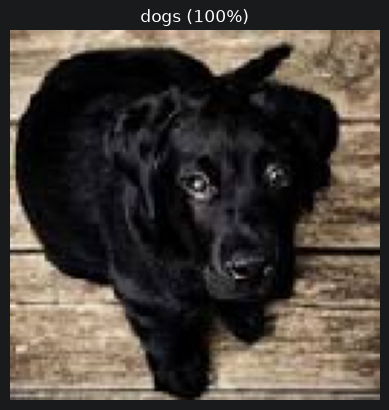

{'cats': '0.2%', 'dogs': '99.8%', 'others': '0.0%'}
download (2).jpg


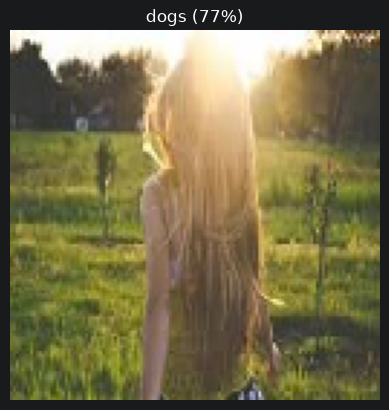

{'cats': '1.6%', 'dogs': '76.8%', 'others': '21.7%'}
download (3).jpg


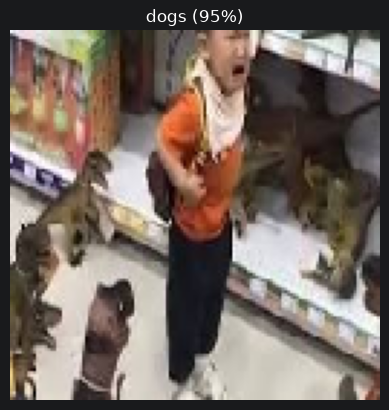

{'cats': '5.2%', 'dogs': '94.8%', 'others': '0.0%'}
download (4).jpg


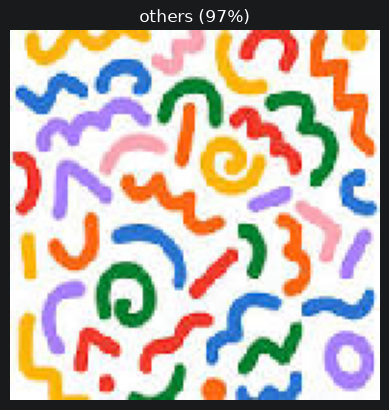

{'cats': '0.3%', 'dogs': '3.0%', 'others': '96.7%'}
download (5).jpg


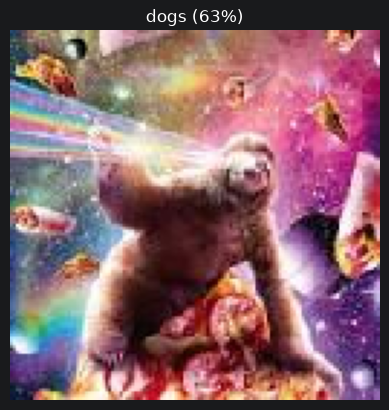

{'cats': '32.9%', 'dogs': '63.2%', 'others': '3.8%'}
download.jpg


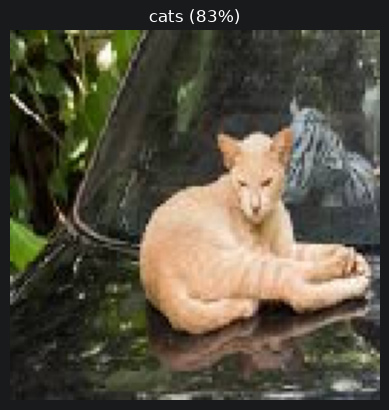

{'cats': '82.6%', 'dogs': '17.3%', 'others': '0.0%'}
images (1).jpg


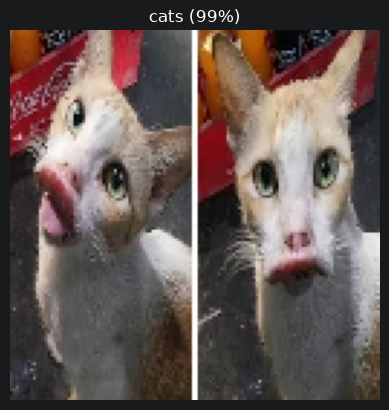

{'cats': '99.2%', 'dogs': '0.8%', 'others': '0.0%'}
images (2).jpg


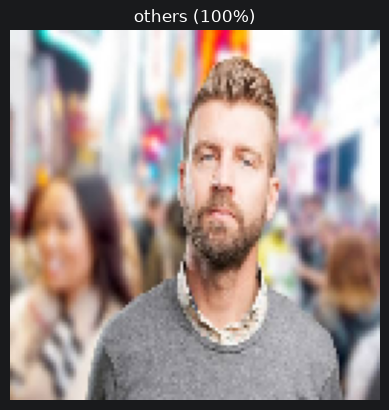

{'cats': '0.0%', 'dogs': '0.0%', 'others': '100.0%'}
images (3).jpg


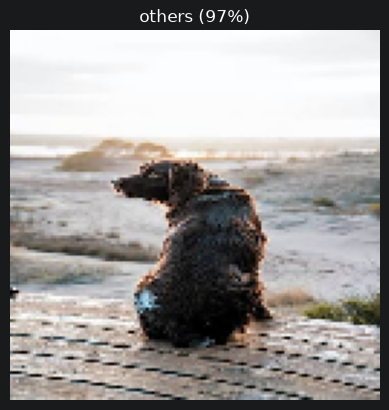

{'cats': '0.0%', 'dogs': '3.3%', 'others': '96.7%'}
images.jpg


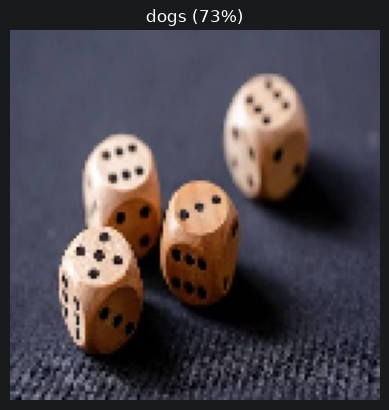

{'cats': '9.5%', 'dogs': '72.6%', 'others': '17.9%'}


In [45]:
folder = r"C:\Users\shind\Downloads\my_tests"

for name in os.listdir(folder):
    if name.lower().endswith((".jpg", ".jpeg", ".png")):
        print(name)
        predict3(os.path.join(folder, name))

In [47]:
def predict_safe(path, threshold=0.80):
    img = load_img(path, target_size=IMG_SIZE)
    arr = np.expand_dims(img_to_array(img), axis=0)
    probs = model3.predict(arr, verbose=0)[0]
    i = int(np.argmax(probs))
    label = class_names[i] if probs[i] >= threshold else "unsure"
    plt.imshow(img)
    plt.title(f"{label} ({probs[i]:.0%})")
    plt.axis("off")
    plt.show()

In [48]:
model3.save("cat_dog_others.keras")

In [49]:
import gradio as gr

def classify3(img):
    img = img.convert("RGB").resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img, dtype="float32"), axis=0)
    probs = model3.predict(arr, verbose=0)[0]
    return {c: float(p) for c, p in zip(class_names, probs)}

demo = gr.Interface(
    fn=classify3,
    inputs=gr.Image(type="pil", label="Upload any photo"),
    outputs=gr.Label(num_top_classes=3),
    title="Cat / Dog / Others Classifier",
)
demo.launch()

C:\Users\shind\PycharmProjects\WelcomeScreen\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [50]:
import numpy as np
import tensorflow as tf
import gradio as gr

IMG_SIZE = (128, 128)
class_names = ["cats", "dogs", "others"]
model3 = tf.keras.models.load_model("cat_dog_others.keras")

def classify3(img):
    img = img.convert("RGB").resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img, dtype="float32"), axis=0)
    probs = model3.predict(arr, verbose=0)[0]
    return {c: float(p) for c, p in zip(class_names, probs)}

gr.Interface(fn=classify3,
             inputs=gr.Image(type="pil"),
             outputs=gr.Label(num_top_classes=3),
             title="Cat / Dog / Others Classifier").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
